<a href="https://colab.research.google.com/github/ashutosh-kedar/pytorch_cv_food_101_tiny_vgg/blob/main/08_PyTorch_Custom_Dataset_Food_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path
import requests
import zipfile

def get_file_from_git(url,file_name,unzip_destination=None):
  file_to_download = Path(file_name)
  if file_to_download.is_file():
    print(f'{file_name} already exists')
  else:
    print(f'Downloading {file_name} from {url}')
    request = requests.get(url)
    with open(file_name,'wb') as file:
      file.write(request.content)

    if file_name.endswith('.zip'):
      with zipfile.ZipFile(file_name,'r') as zip_ref:
        print('Unzipping the zip file...')
        zip_ref.extractall(Path(unzip_destination))

In [ ]:
model_url = 'https://raw.githubusercontent.com/ashutosh-kedar/pytorch_cv_food_101_tiny_vgg/main/tiny_vgg_model.pth'

get_file_from_git(model_url,'tiny_vgg_model.pth')


In [ ]:
custom_image_url = 'https://raw.githubusercontent.com/ashutosh-kedar/pytorch_cv_food_101_tiny_vgg/main/Ice_cream.jpg'
get_file_from_git( custom_image_url ,'Ice_cream.jpg')

In [ ]:
from torch import nn


class TinyVgg(nn.Module):
  def __init__(self,input_size,hidden_size,output_size):
    super().__init__()
    self.conv1 = nn.Sequential(
      nn.Conv2d(in_channels=input_size,out_channels=hidden_size,kernel_size=3,stride=1,padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.conv2 = nn.Sequential(
      nn.Conv2d(in_channels=hidden_size,out_channels=hidden_size,kernel_size=3,stride=1,padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=hidden_size*56*56,out_features=output_size)
  )

  def forward(self,x):
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.classifier(x)
    return x



In [ ]:
from torchvision import transforms
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
tiny_vgg_model = TinyVgg(input_size=3,hidden_size=10,output_size=3)
tiny_vgg_model

TinyVgg(
  (conv1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=31360, out_features=3, bias=True)
  )
)

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import torch

def predict_image(model,image_path,class_names,transform,device):

  model.eval()
  model.to(device)
  with Image.open(image_path) as image:
    numpy_array = np.array(image)
    numpy_array = numpy_array / 255
    image = transform(image)
    image = image.unsqueeze(0)
    image = image.to(device)
    with torch.inference_mode():
      pred_logits = model(image)
      pred_label = torch.argmax(torch.softmax(pred_logits,dim=1),dim=1)

    plt.imshow(numpy_array)
    plt.title(f'Prediction: {class_names[pred_label]}')
    plt.axis(False)

    return class_names[pred_label],pred_logits


In [ ]:
from pathlib import Path
model_name = Path('tiny_vgg_model.pth')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
labels = ['ice_cream', 'pizza', 'fried_rice']

tiny_vgg_model.load_state_dict(torch.load(f=model_name))

<All keys matched successfully>

('ice_cream', tensor([[ 0.5061, -0.4521, -0.6874]]))

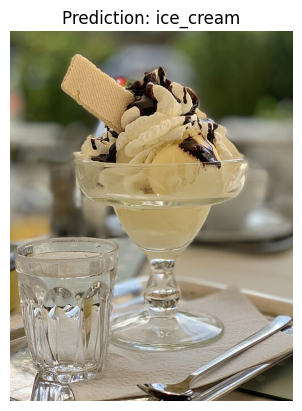

In [ ]:
tiny_vgg_model.eval()
custom_img_result_new = predict_image(tiny_vgg_model,'Ice_cream.jpg',labels,test_transforms,device)
custom_img_result_new